In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Paths ─────────────────────────────────────────────────────────────────────
GRID_PARQUET_PATH  = "../outputs/grid_assigned.parquet"
GRID_GPKG_PATH     = "../outputs/denmark_grid.gpkg"
ADMIN_GPKG_PATH    = "../outputs/denmark_admin.gpkg"   # for the boundary overlay

In [2]:
# ── Load the grid parquet (records with grid_cell_id labels) ──────────────────
df_grid = pd.read_parquet(GRID_PARQUET_PATH)

print(f"Records loaded     : {len(df_grid):,}")
print(f"Unique grid cells  : {df_grid['grid_cell_id'].nunique():,}")
print(f"Unique species     : {df_grid['species'].nunique():,}")
unique_species = df_grid['species'].nunique()

Records loaded     : 30,138,961
Unique grid cells  : 134
Unique species     : 510


In [3]:
# ── Compute species richness per grid cell ────────────────────────────────────
# groupby grid_cell_id, then nunique on species column
# Result is a small table: one row per cell, one column for richness

richness = (
    df_grid
    .groupby("grid_cell_id")["species"]
    .nunique()
    .reset_index()
    .rename(columns={"species": "species_richness"})
)

print(f"Grid cells with at least 1 record : {len(richness):,}")
print(f"\nSpecies richness summary:")
print(richness["species_richness"].describe())

Grid cells with at least 1 record : 134

Species richness summary:
count    134.000000
mean     256.111940
std       49.581657
min       16.000000
25%      237.000000
50%      260.500000
75%      285.000000
max      374.000000
Name: species_richness, dtype: float64


In [4]:
# ── Define hotspot threshold ───────────────────────────────────────────────────
HOTSPOT_FRACTION = 0.65
HOTSPOT_THRESHOLD = unique_species * HOTSPOT_FRACTION

# Any cell with species_richness >= 434 is a hotspot
hotspots    = richness[richness["species_richness"] >= HOTSPOT_THRESHOLD]
non_hotspot = richness[richness["species_richness"] <  HOTSPOT_THRESHOLD]

print(f"Total unique species          : {unique_species}")
print(f"Hotspot threshold (85%)       : {HOTSPOT_THRESHOLD:.1f} → cells with ≥ 332 species")
print(f"Hotspot cells                 : {len(hotspots):,}")
print(f"Non-hotspot cells with records: {len(non_hotspot):,}")
print(f"\nHotspot richness range: "
      f"{hotspots['species_richness'].min()} – {hotspots['species_richness'].max()}")

Total unique species          : 510
Hotspot threshold (85%)       : 331.5 → cells with ≥ 332 species
Hotspot cells                 : 5
Non-hotspot cells with records: 129

Hotspot richness range: 334 – 374


In [5]:
# ── Load the grid geometry from the GeoPackage ────────────────────────────────
# This GeoDataFrame has the polygon shapes for every grid cell along with the grid_cell_id column which we use to merge

grid_gdf = gpd.read_file(GRID_GPKG_PATH)

print(f"Grid cells in GeoPackage : {len(grid_gdf):,}")
print(f"Columns                  : {grid_gdf.columns.tolist()}")
print(f"CRS                      : {grid_gdf.crs}")

Grid cells in GeoPackage : 134
Columns                  : ['lat_bin', 'lon_bin', 'grid_cell_id', 'geometry']
CRS                      : EPSG:4326


In [6]:
# ── Merge richness values onto the grid geometry ──────────────────────────────
# This is a standard pandas merge on the grid_cell_id column.
# how="left" keeps ALL grid cells, even ones with no records.
# Those cells will have NaN for species_richness, which we fill with 0
# because a cell with no records has observed richness of zero.

grid_richness = grid_gdf.merge(
    richness,
    on="grid_cell_id",
    how="left"
)

grid_richness["species_richness"] = grid_richness["species_richness"].fillna(0)

print(f"Cells with records    : {(grid_richness['species_richness'] > 0).sum():,}")
print(f"Cells with no records : {(grid_richness['species_richness'] == 0).sum():,}")
print(f"\nRichness range: {grid_richness['species_richness'].min():.0f} "
      f"– {grid_richness['species_richness'].max():.0f}")

Cells with records    : 134
Cells with no records : 0

Richness range: 16 – 374


In [7]:
# ── Load Denmark boundary for overlay ────────────────────────────────────────
# We use the admin gpkg just to get the national outline for context
# Dissolve merges all 5 region polygons into one national boundary polygon
denmark_outline = gpd.read_file(ADMIN_GPKG_PATH).dissolve()

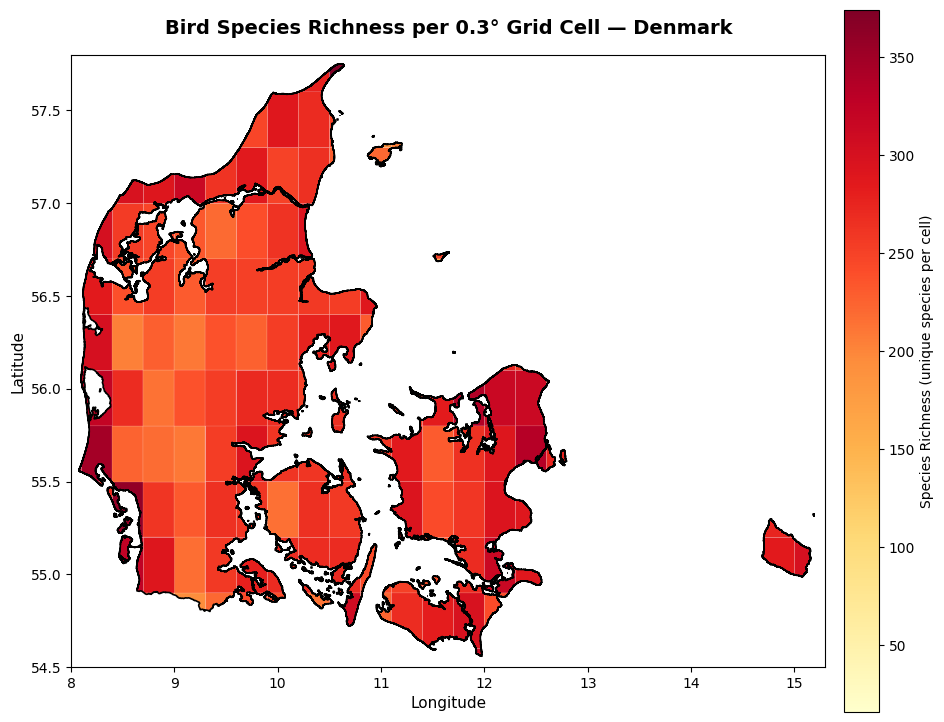

Plot saved to ../outputs/species_richness_grid.png


In [8]:
# ── Plot species richness choropleth ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 12))

# Plot cells with zero records in a neutral grey so they are visually
# distinct from low-richness cells rather than appearing as the lowest
# colour in the colourmap — this is an important visual honesty choice
# ------ UPDATE: There are no cells with 0 records as shown in the above summary statistics, so we skip this step. If there were any, we would plot them here. ------- 
# no_records = grid_richness[grid_richness["species_richness"] == 0]


has_records = grid_richness[grid_richness["species_richness"] > 0]

#no_records.plot(
#    ax=ax,
#    color="#e0e0e0",   # neutral grey for unsampled cells
#    edgecolor="white",
#    linewidth=0.1
#)

# Plot cells with records using a sequential colourmap
# YlOrRd (yellow → orange → red) works well for richness:
# pale yellow = low richness, dark red = high richness
has_records.plot(
    ax=ax,
    column="species_richness",
    cmap="YlOrRd",
    edgecolor="white",
    linewidth=0.1,
    legend=True,
    legend_kwds={
        "label"      : "Species Richness (unique species per cell)",
        "orientation": "vertical",
        "shrink"     : 0.6,
        "pad"        : 0.02
    }
)

# Overlay Denmark's national boundary as a black outline for geographic context
denmark_outline.plot(
    ax=ax,
    color="none",
    edgecolor="black",
    linewidth=1.2
)

ax.set_title(
    f"Bird Species Richness per 0.3° Grid Cell — Denmark",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude", fontsize=11)

# Set axis limits tightly around Denmark
ax.set_xlim(8.0, 15.3)
ax.set_ylim(54.5, 57.8)

plt.tight_layout()
plt.savefig("../outputs/species_richness_grid.png", dpi=1600, bbox_inches="tight")
plt.show()

print("Plot saved to ../outputs/species_richness_grid.png")